In [1]:
import numpy as np
import pandas as pd
from glob import glob
from matplotlib import pyplot as plt
import seaborn as sns
import pickle as pkl
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from one.api import ONE
from sklearn.decomposition import PCA
from dPCA import dPCA
from sklearn.metrics import euclidean_distances
from scipy import stats
from manifold.pseudosession_manifolds import analyze_stitched_manifold

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import plotly.io as pio

pio.renderers.default = "notebook"

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
def get_region_stats():
    one = ONE()
    units_df = bwm_units(one)
    neuron_counts = units_df.groupby(["Beryl", "eid"]).size().reset_index(name="neuron_count")
    valid_pairings = neuron_counts[neuron_counts["neuron_count"] >= 5]
    # print(valid_pairings)  # atleast 10 neurons
    final_counts = (
        valid_pairings.groupby("Beryl")["eid"]
        .nunique()
        .reset_index(name="valid_eid_count")
        .sort_values(by="valid_eid_count", ascending=False)
    )
    # print(final_counts)
    regions_of_interest = final_counts[final_counts["valid_eid_count"] >= 20]["Beryl"].values
    region_totals = units_df.groupby("Beryl").size()
    valid_regions = region_totals[region_totals >= 20].index
    df_valid = units_df[units_df["Beryl"].isin(valid_regions)]

    final_table = (
        df_valid.groupby("Beryl")["eid"]
        .agg(
            total_neurons="size",
            unique_eid_count="nunique",
            eids_list=lambda x: list(x.unique()),
        )
        .reset_index()
        .sort_values(by="total_neurons", ascending=False)
    )
    # final_table[final_table["unique_eid_count"] >= 10]["Beryl"].values
    return final_table, final_counts

In [6]:
files = np.sort(glob("../data/generated/manifold/true_results/*.pkl"))
pseudo_files = np.sort(glob("../data/generated/manifold/pseudosession/*.pkl"))

In [7]:
def plot_trajectories(traj_A, traj_B,region):
    import plotly.graph_objects as go

    trace_A = go.Scatter3d(
        x=traj_A[:, 0],
        y=traj_A[:, 1],
        z=traj_A[:, 2],
        mode="lines+markers",
        line=dict(color="blue", width=4),
        marker=dict(
            size=[8] + [2] * (len(traj_A) - 1), color="blue"
        ),  # Makes the first dot bigger
        name="Correct",
    )

    trace_B = go.Scatter3d(
        x=traj_B[:, 0],
        y=traj_B[:, 1],
        z=traj_B[:, 2],
        mode="lines+markers",
        line=dict(color="red", width=4),
        marker=dict(size=[8] + [2] * (len(traj_B) - 1), color="red"),  # Makes the first dot bigger
        name="Incorrect",
    )

    fig = go.Figure(data=[trace_A, trace_B])

    fig.update_layout(
        title=f"{region}",
        scene=dict(xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="PC 3"),
        width=400,
        height=400,
    )
    fig.show()

In [8]:
def get_trajectory_data(data, unstiched=True):

    if unstiched:
        stiched_session = []
        for k in data.keys():
            stiched_session.append(data[k])
        stiched_session = np.concatenate(stiched_session)
    else:
        stiched_session = data
    
    pca = PCA(n_components=3)
    pca_session = pca.fit_transform(stiched_session.T)
    # print(pca_session.shape)
    n_timepoints = 50
    cond_A_data = pca_session[0:n_timepoints,:]
    cond_B_data = pca_session[n_timepoints:,:]

    return  pca.explained_variance_ratio_, stiched_session[:,0:50], stiched_session[:, 50:], stiched_session.shape


In [99]:
def get_trajectory_data_plot(data,region=""):

    
    stiched_session = []
    for k in data.keys():
        stiched_session.append(data[k])
    stiched_session = np.concatenate(stiched_session)
     
    pca = PCA(n_components=3)
    pca_session = pca.fit_transform(stiched_session.T)
    # print(pca_session.shape)
    n_timepoints = 50
    cond_A_data = pca_session[0:n_timepoints,:]
    cond_B_data = pca_session[n_timepoints:,:]
    plot_trajectories(cond_A_data, cond_B_data,region)


In [9]:
def compute_participation_ratio(trajectory):
    cov_matrix = np.cov(trajectory, bias=True)
    
    trace_cov = np.trace(cov_matrix)
    trace_cov_sq = np.trace(np.dot(cov_matrix, cov_matrix))
    
    if trace_cov_sq == 0:
        return 0.0
        
    return (trace_cov ** 2) / trace_cov_sq

In [10]:
def transpose_and_stitch_fast(data):
    stiched_session = []
    for k in data.keys():
        stiched_session.append(data[k])

    n_pseudosessions = len(stiched_session[0])
    
    return np.asarray([
        np.vstack([session_data[p] for session_data in stiched_session]) 
        for p in range(n_pseudosessions)
    ])

In [42]:
from scipy.stats import zscore

In [68]:
def analyze_full_space_manifold(balanced_supersession, n_timepoints=50):
    """

    balanced_supersession: shape (N_neurons, 100)
    """
    # balanced_supersession = zscore(balanced_supersession, axis=1)
    # balanced_supersession = np.nan_to_num(balanced_supersession, nan=0.0)
    
    cond_correct = balanced_supersession[:, :n_timepoints]   # Shape: (N, 50)
    cond_incorrect = balanced_supersession[:, n_timepoints:] # Shape: (N, 50)


    len_correct = np.sum(np.linalg.norm(np.diff(cond_correct, axis=1), axis=0))
    len_incorrect = np.sum(np.linalg.norm(np.diff(cond_incorrect, axis=1), axis=0))
    path_length_diff = len_incorrect - len_correct 


    steps_correct = np.abs(np.diff(cond_correct, axis=1))
    steps_incorrect = np.abs(np.diff(cond_incorrect, axis=1))
    

    dist_neuron_correct = np.sum(steps_correct, axis=1)
    dist_neuron_incorrect = np.sum(steps_incorrect, axis=1)
    
    dist_diff = dist_neuron_incorrect - dist_neuron_correct

    
    return  path_length_diff, dist_diff

In [93]:
from statsmodels.stats.multitest import multipletests

In [69]:
def get_stiched_supersession(data):
    stiched_session_super = []
    for k in data.keys():
        stiched_session_super.append(data[k])
    stiched_session_super = np.concatenate(stiched_session_super)
    return stiched_session_super

In [70]:
rnames = []
for idx in range(len(files)):
    fname = files[idx]
    rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]
    rnames.append(rname)


In [ ]:
region_results_path = {}
region_results_neuron = {}

for idx in range(len(files)):
    fname = files[idx]
    fname_pseudo = pseudo_files[idx]
    rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]

    
    with open(fname, "rb") as f:
        true_data = pkl.load(f)
    with open(fname_pseudo, "rb") as f:
        pseudo_data = pkl.load(f)

    stiched_session_true = get_stiched_supersession(true_data)
    stacked_pseudo = transpose_and_stitch_fast(pseudo_data)

    
    true_path_length_diff, true_dist_diff_array = analyze_full_space_manifold(stiched_session_true)
    
    
    true_mean_dist_diff = np.mean(true_dist_diff_array)

    
    null_path_diffs = []
    null_mean_dist_diffs = []
    all_pseudo_dist_arrays = [] 

    for pseudo_n in range(len(stacked_pseudo)): 
        pseudo_path_diff, pseudo_dist_diff_array = analyze_full_space_manifold(stacked_pseudo[pseudo_n])
        
        null_path_diffs.append(pseudo_path_diff)
        null_mean_dist_diffs.append(np.mean(pseudo_dist_diff_array))
        all_pseudo_dist_arrays.append(pseudo_dist_diff_array)

    
    region_results_path[rname] = {
        "true_diff": true_path_length_diff,
        "null_diffs": null_path_diffs
    }
    
    region_results_neuron[rname] = {
        "true_diff": true_mean_dist_diff,
        "null_diffs": null_mean_dist_diffs
    }

    
    fig, ax = plt.subplots(figsize=(5,5))
    
    
    sns.kdeplot(true_dist_diff_array, color='blue', label='True', ax=ax)

    for i in range(5): 
        sns.kdeplot(all_pseudo_dist_arrays[i], color='red', alpha=0.3, ax=ax)
        
    ax.set_title(f'{rname} - Single Neuron Distance Diffs')
    ax.legend()
    plt.show()

In [94]:
def compute_significance_and_fdr(region_results, alpha=0.05, tail="greater"):
    """
    Computes permutation p-values and applies FDR correction across all regions.
    
    """
    regions = list(region_results.keys())
    raw_p_values = []
    
    
    for region in regions:
        true_diff = region_results[region]["true_diff"]
        null_diffs = np.array(region_results[region]["null_diffs"])
        n_pseudos = len(null_diffs)
        
        if tail == "two-sided":
            n_extreme = np.sum(np.abs(null_diffs) >= np.abs(true_diff))
        elif tail == "greater":
            n_extreme = np.sum(null_diffs >= true_diff)
        elif tail == "less":
            n_extreme = np.sum(null_diffs <= true_diff)
            
        p_val = (n_extreme + 1) / (n_pseudos + 1)
        raw_p_values.append(p_val)
        
    reject_mask, fdr_p_values, _, _ = multipletests(
        raw_p_values, alpha=alpha, method='fdr_bh'
    )
    
    
    final_stats = {}
    for i, region in enumerate(regions):
        final_stats[region] = {
            "p_raw": raw_p_values[i],
            "p_fdr": fdr_p_values[i],
            "is_significant": reject_mask[i]
        }
        
    return final_stats

In [ ]:

for r in rnames:
    sig_path = compute_significance_and_fdr(region_results_path, alpha=0.05, tail="two-sided")
    sig_neuron = compute_significance_and_fdr(region_results_neuron, alpha=0.05, tail="two-sided")
    print(f"{r} Path Length Significant? {sig_path[r]['is_significant']}")
    print(f"{r} Neuron Volatility Significant? {sig_neuron[r]['is_significant']}")

In [106]:
def plot_trajectories_matplotlib(traj_A, traj_B, region):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    ax.plot(traj_A[:, 0], traj_A[:, 1], traj_A[:, 2], 
            color='blue', label='Correct', linewidth=1.5, marker='o', markersize=3)
    
    ax.plot(traj_B[:, 0], traj_B[:, 1], traj_B[:, 2], 
            color='red', label='Incorrect', linewidth=1.5, marker='o', markersize=3)


    ax.scatter(*traj_A[0, :], color='blue', s=80, edgecolor='black', zorder=5)
    ax.scatter(*traj_B[0, :], color='red', s=80, edgecolor='black', zorder=5)

    ax.scatter(*traj_A[-1, :], color='blue', s=80, edgecolor='black', zorder=5,marker='*')
    ax.scatter(*traj_B[-1, :], color='red', s=80, edgecolor='black', zorder=5,marker='*')


    ax.set_title(f"{region}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [107]:
def get_trajectory_data_plot_matplotlib(data,region=""):

    
    stiched_session = []
    for k in data.keys():
        stiched_session.append(data[k])
    stiched_session = np.concatenate(stiched_session)
     
    pca = PCA(n_components=3)
    pca_session = pca.fit_transform(stiched_session.T)
    # print(pca_session.shape)
    n_timepoints = 50
    cond_A_data = pca_session[0:n_timepoints,:]
    cond_B_data = pca_session[n_timepoints:,:]
    plot_trajectories_matplotlib(cond_A_data, cond_B_data,region)


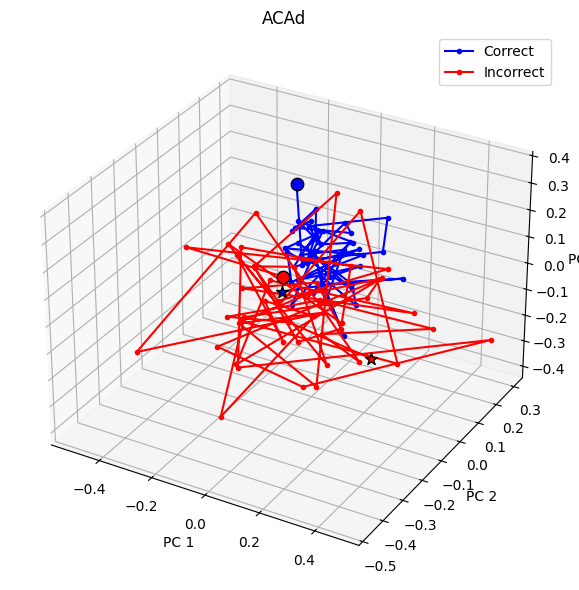

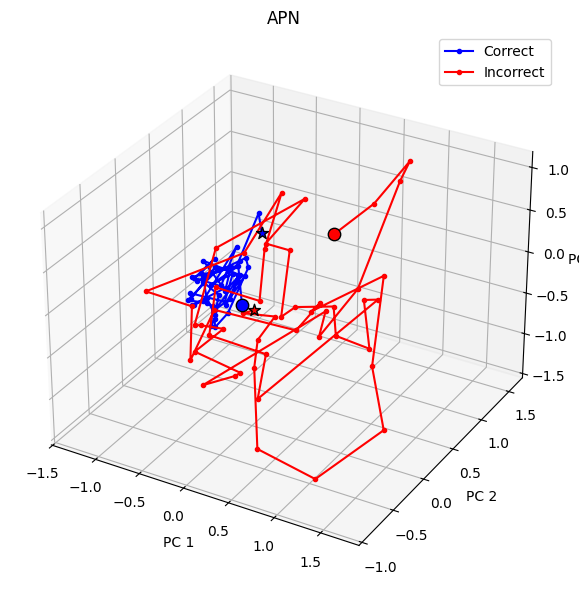

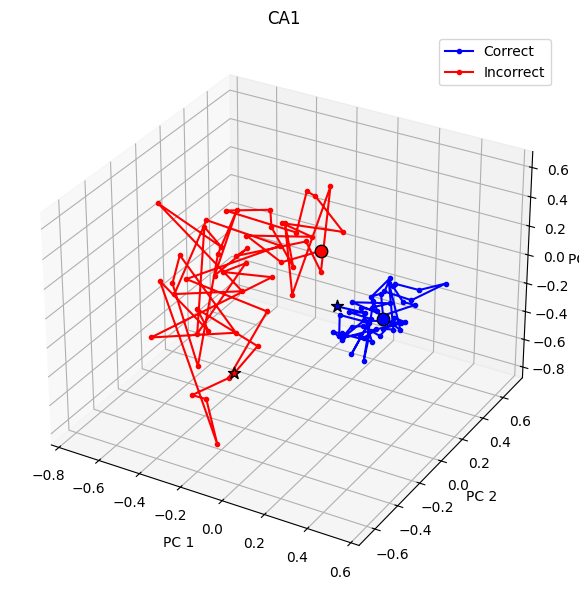

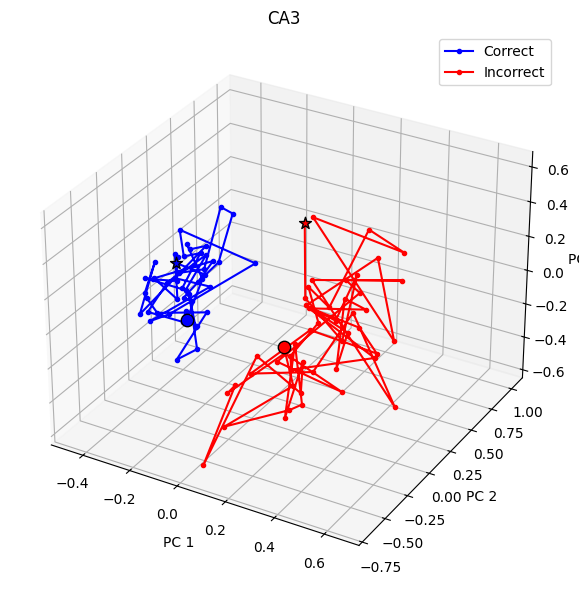

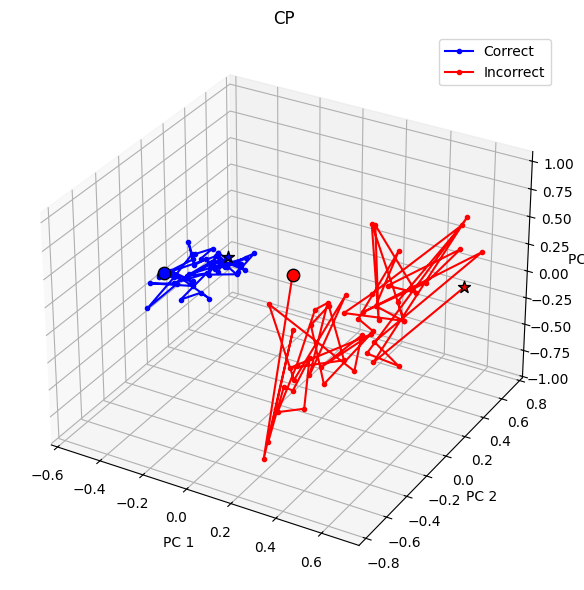

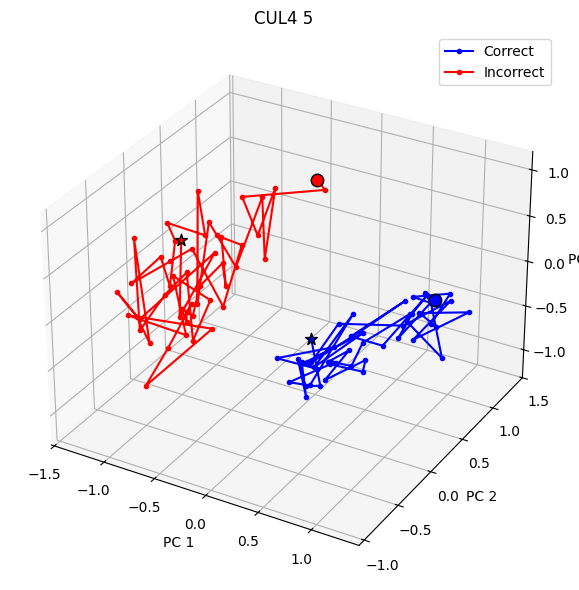

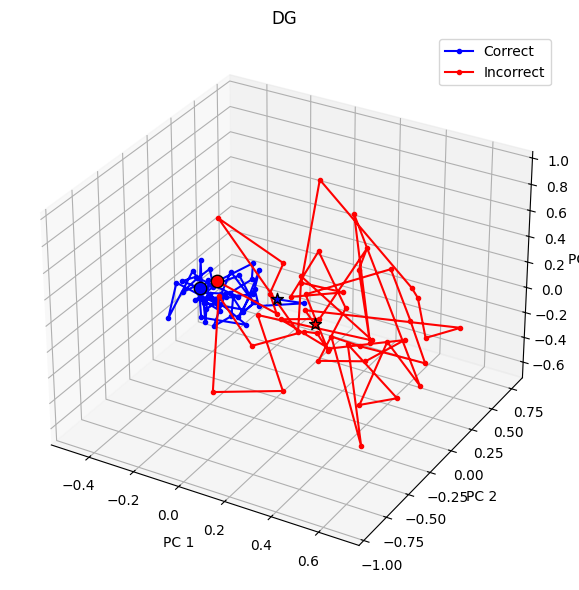

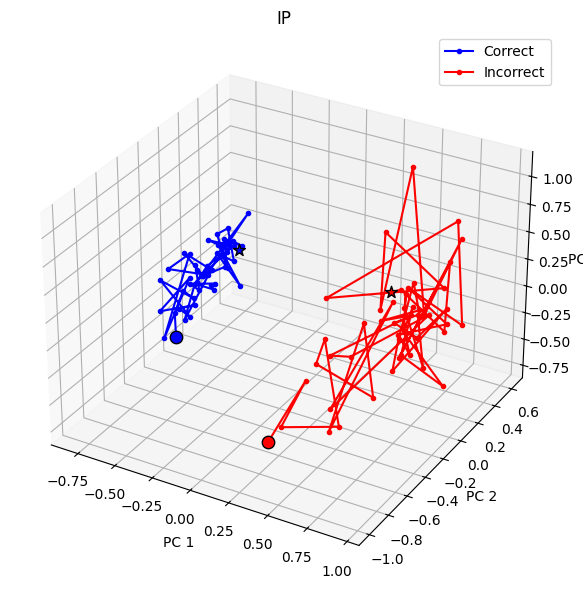

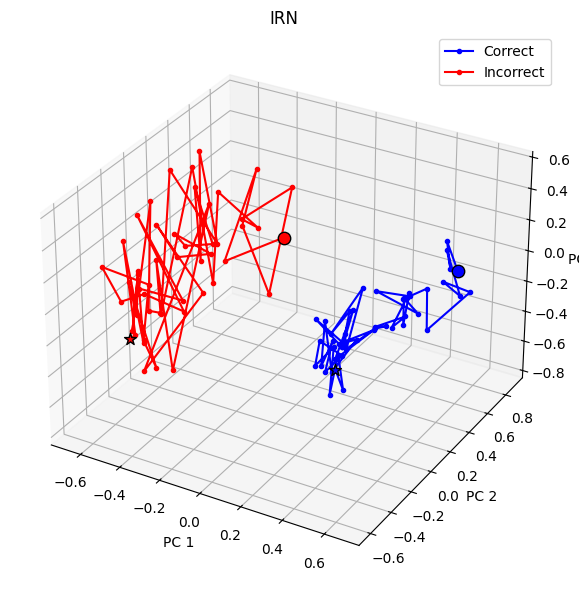

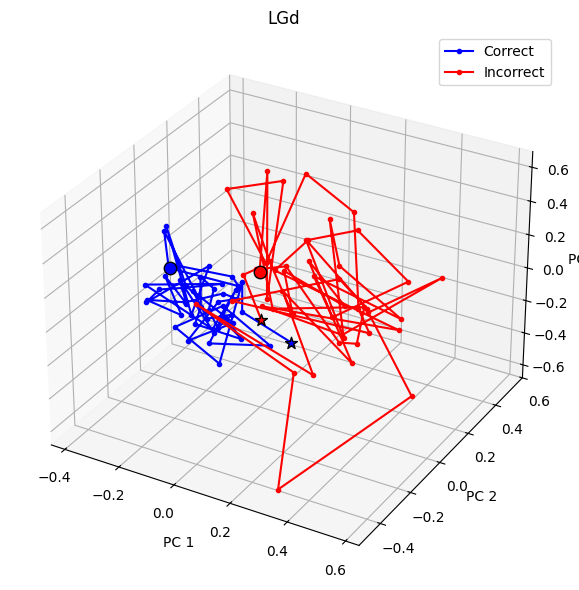

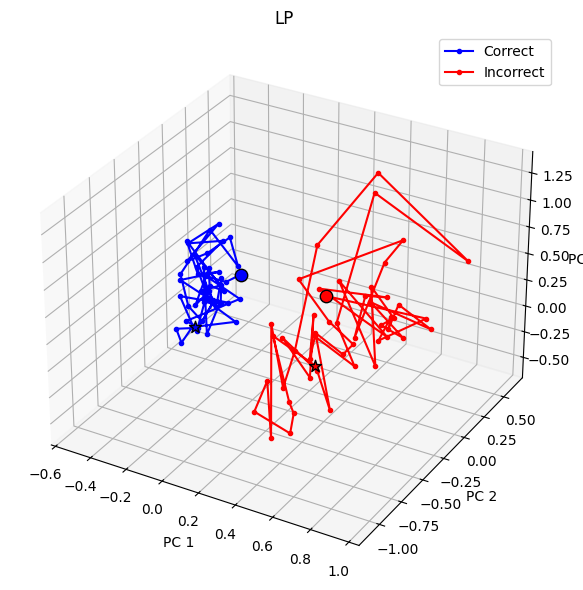

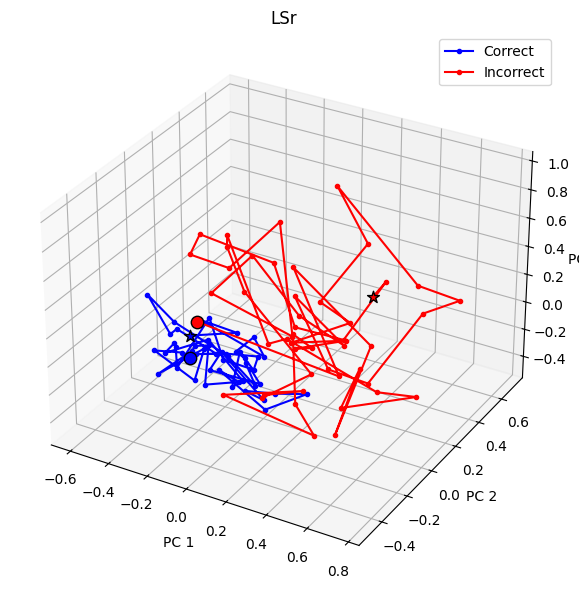

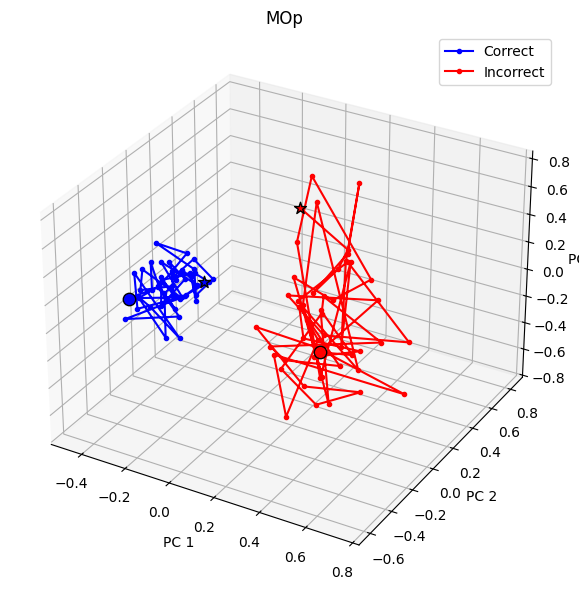

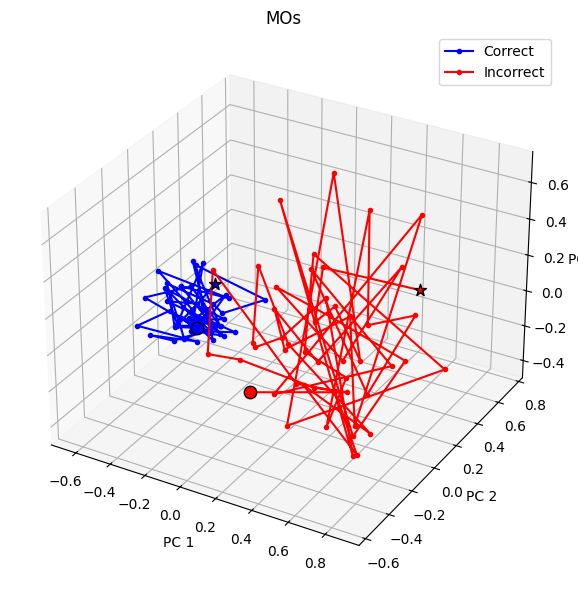

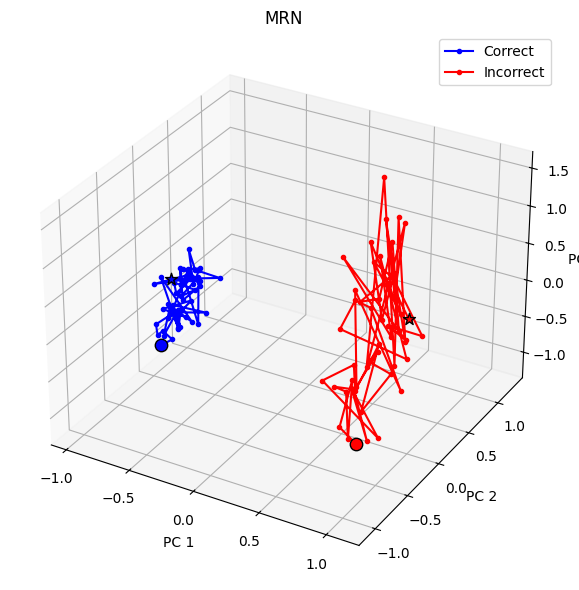

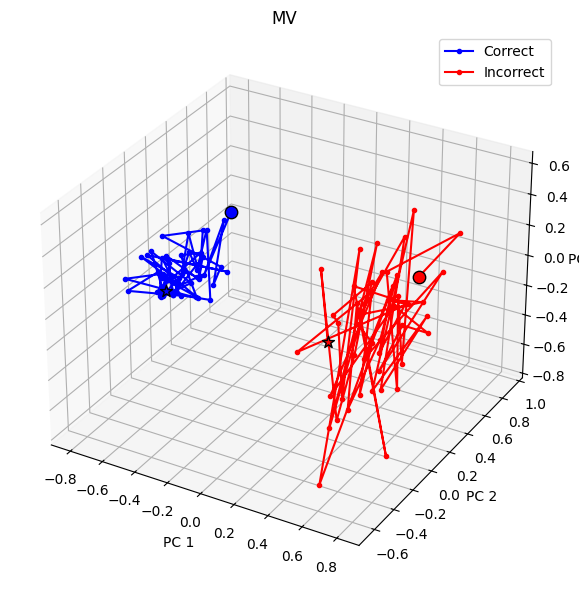

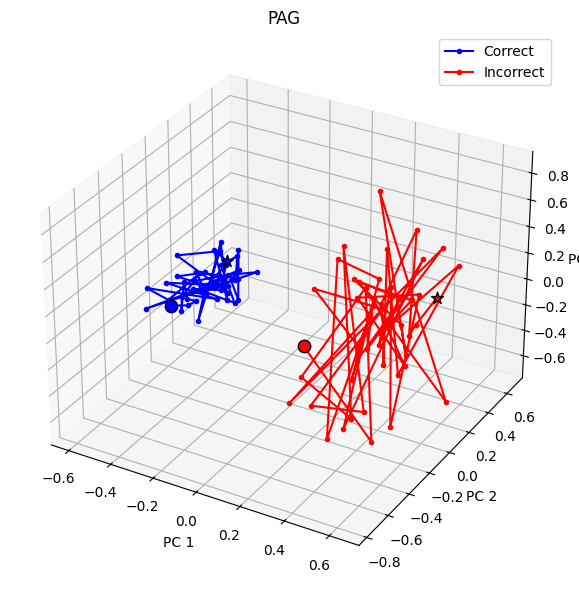

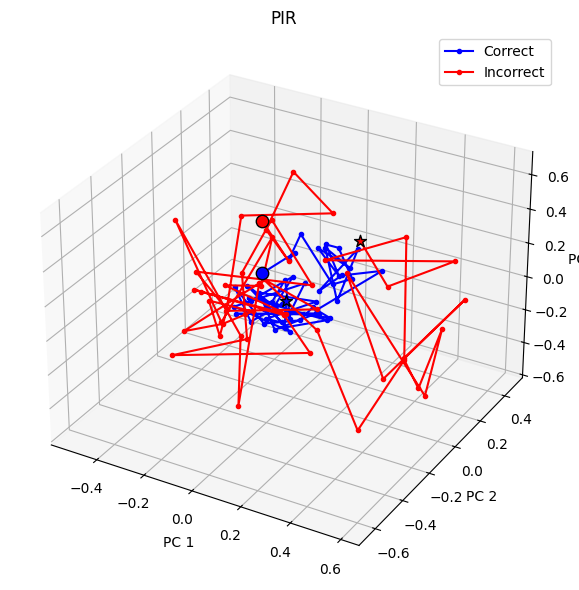

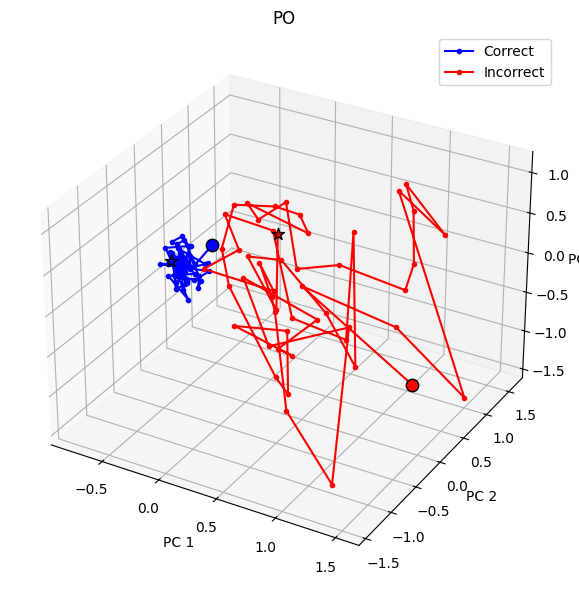

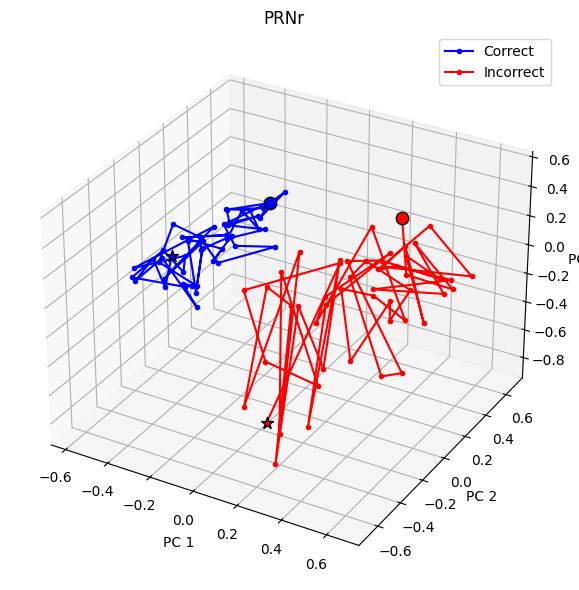

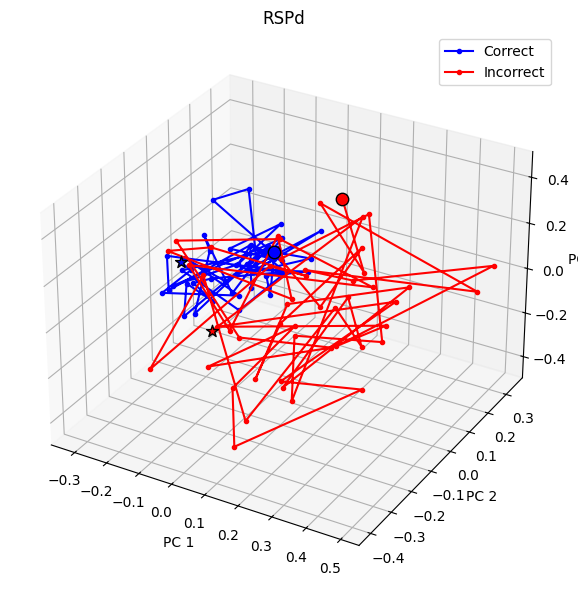

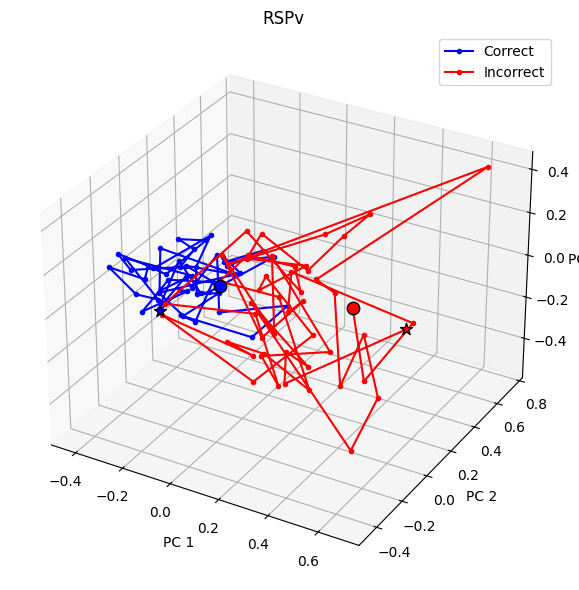

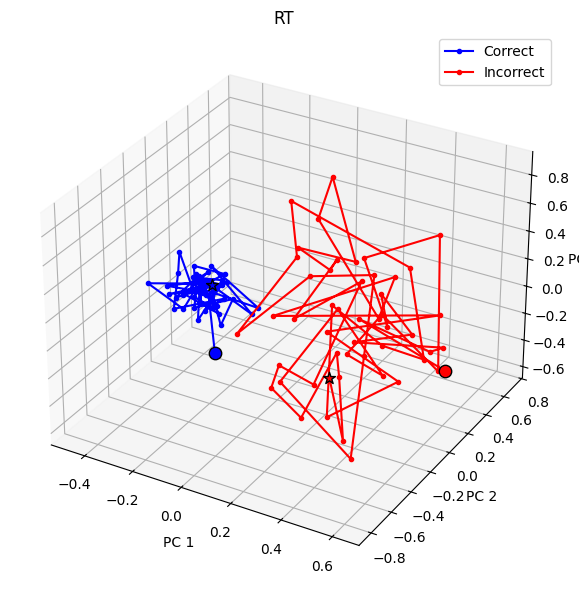

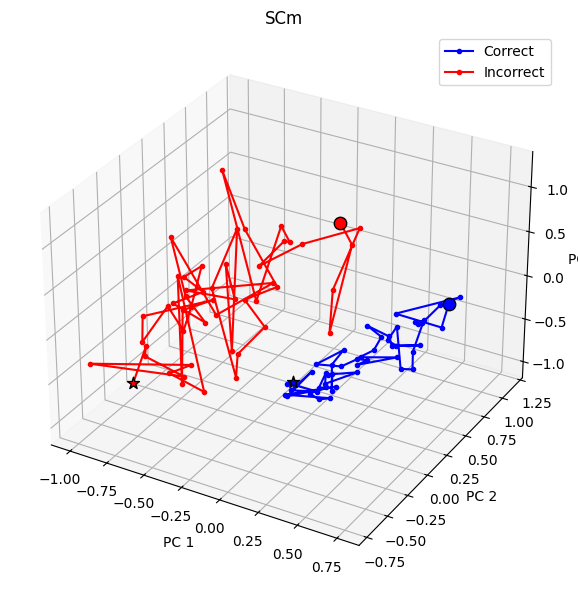

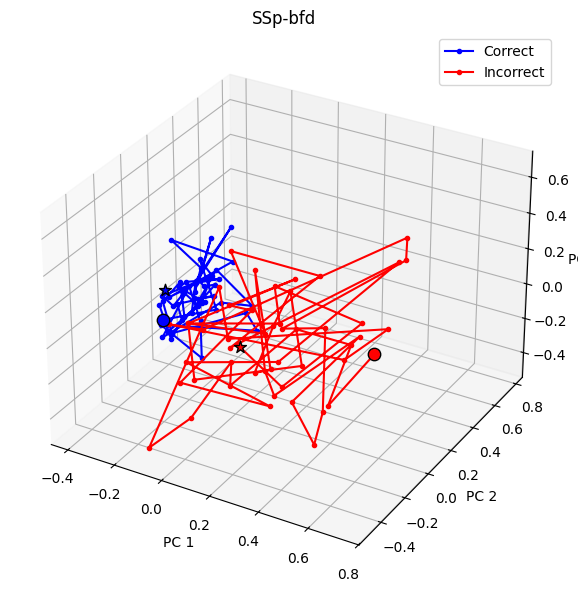

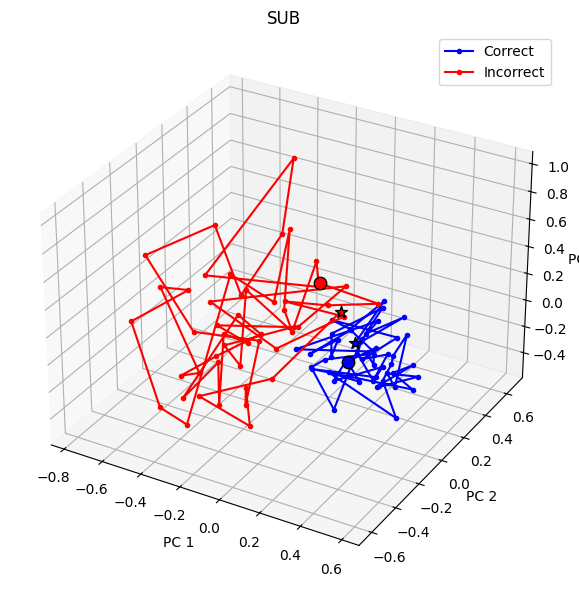

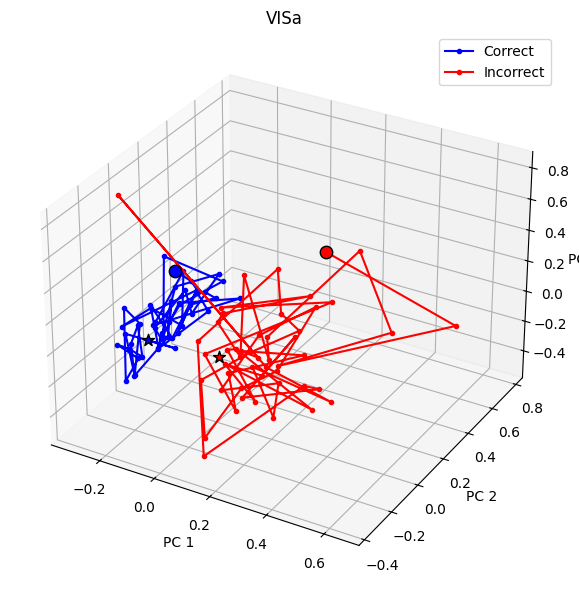

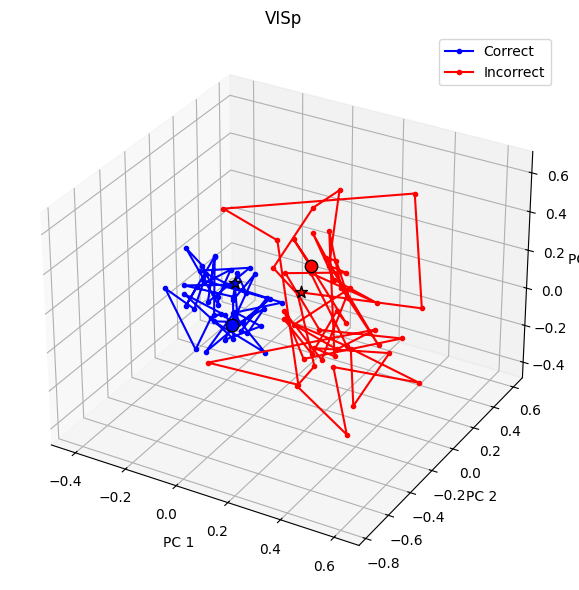

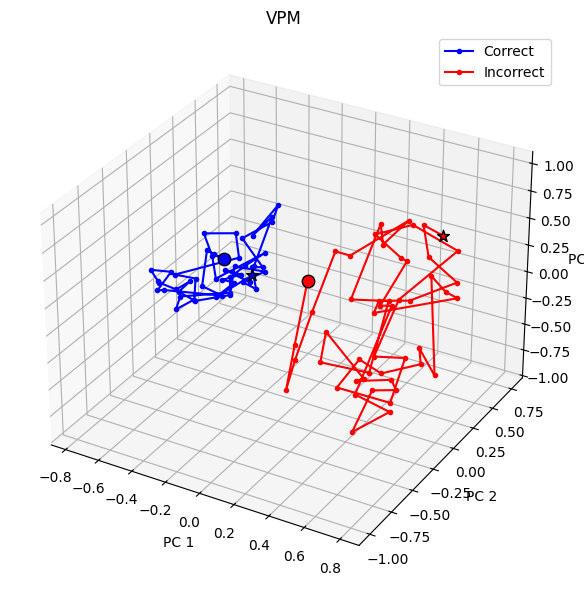

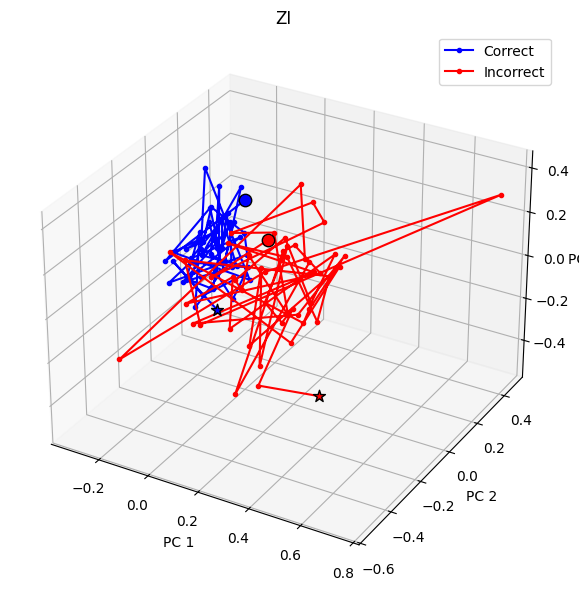

In [108]:
for idx in range(len(files)):
    fname = files[idx]
    fname_pseudo = pseudo_files[idx]
    rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]

    
    with open(fname, "rb") as f:
        true_data = pkl.load(f)
    
    get_trajectory_data_plot_matplotlib(true_data, rname)
    